# GECS — FLANG-DeBERTa Champion (Task 1 v9)

**Model:** SALT-NLP/FLANG-DEBERTA | **Data:** cleaned_v9 dual-signal | **Runtime:** Colab A100

**Training:** 4 CE + 4 Focal (gamma=1.0) + 4 CE low LR — matches friend's champion schedule

**CRITICAL:** fp32 mandatory — DeBERTa-v3 XSoftmax produces NaN with bf16. Never set use_bf16=True.

In [ ]:
import torch
if not torch.cuda.is_available():
    raise RuntimeError('No GPU. Runtime > Change runtime type > A100')
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('Ready.')

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
Ready.


In [ ]:
!pip install transformers accelerate -q
print('Done.')

Done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

BASE_DIR  = Path('/content/drive/MyDrive/CAPSTONE')
CLEAN_DIR = BASE_DIR / 'cleaned_v9'
ART_DIR   = BASE_DIR / 'flang_deberta_champion_artifacts'
ART_DIR.mkdir(parents=True, exist_ok=True)

FILE_T1     = CLEAN_DIR / 'task1_gecs_cleaned_v9.csv'
FILE_HIER   = BASE_DIR  / 'cleaned_v6' / 'industries_Hierarchy.csv'
SPLITS_FILE = CLEAN_DIR / 'canonical_splits.npz'
EXPERIMENTS_LOG = ART_DIR / 'experiments_log.csv'

print('Path check:')
for f in [FILE_T1, FILE_HIER, SPLITS_FILE]:
    print(('  OK' if f.exists() else '  NOT FOUND'), f.name)

Mounted at /content/drive
Path check:
  OK task1_gecs_cleaned_v9.csv
  OK industries_Hierarchy.csv
  OK canonical_splits.npz


In [ ]:
import time, json, warnings, pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings('ignore')
device = torch.device('cuda')
print(f'Device: {device}')

Device: cuda


In [ ]:
CFG = {
    # FLANG-DeBERTa — finance domain + DeBERTa-v3 architecture
    'model_name': 'SALT-NLP/FLANG-BERT',            # Already have this
    'max_len'          : 360,
    'dropout'          : 0.1,
    'num_features'     : 10,
    'use_bf16'         : False,    # NEVER True — DeBERTa-v3 NaN prevention

    # Multi-task auxiliary heads
    'aux_weight_sector': 0.15,
    'aux_weight_group' : 0.20,

    # 3-phase: 4 CE + 4 Focal (gamma=1.0) + 4 CE low LR
    # Matches friend's champion training schedule
    'phase1_epochs'    : 4,        # CE warmup
    'phase2_epochs'    : 4,        # Focal hard example mining
    'phase3_epochs'    : 4,        # CE low LR extended tuning
    'lr_phase1'        : 2e-5,
    'lr_phase2'        : 2e-5,
    'lr_phase3'        : 5e-6,
    'warmup_ratio'     : 0.1,

    # Layer-wise LR decay — prevents catastrophic forgetting
    'llrd_factor'      : 0.95,     # decay per layer from top to bottom

    # Batch — fp32 needs smaller batch
    'batch_size_train' : 16,
    'batch_size_eval'  : 32,

    # Loss
    'label_smoothing'  : 0.05,
    'focal_gamma'      : 1.0,      # gentle — matches friend's config
    'focal_weight_cap' : 2.0,      # matches friend's class weight cap
    'weight_power'     : 0.5,

    'seed'             : 42,
}
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Config — FLANG-DeBERTa Champion | 3-phase CE+Focal+CE | fp32 | LLRD')
print(f'  Phase 1: {CFG["phase1_epochs"]} epochs CE @ {CFG["lr_phase1"]}')
print(f'  Phase 2: {CFG["phase2_epochs"]} epochs Focal (gamma={CFG["focal_gamma"]}) @ {CFG["lr_phase2"]}')
print(f'  Phase 3: {CFG["phase3_epochs"]} epochs CE @ {CFG["lr_phase3"]}')
print(f'  LLRD factor: {CFG["llrd_factor"]}')
print('WARNING: bf16=False is mandatory for DeBERTa-v3')

Config — FLANG-DeBERTa Champion | 3-phase CE+Focal+CE | fp32 | LLRD
  Phase 1: 4 epochs CE @ 2e-05
  Phase 2: 4 epochs Focal (gamma=1.0) @ 2e-05
  Phase 3: 4 epochs CE @ 5e-06
  LLRD factor: 0.95


In [ ]:
t1   = pd.read_csv(FILE_T1, dtype={'MstarGlobal': str})
hier = pd.read_csv(FILE_HIER, dtype={'industry_id': str})

splits       = np.load(SPLITS_FILE)
t1_train_idx = splits['t1_train_idx']
t1_test_idx  = splits['t1_test_idx']

le = LabelEncoder()
le.fit(t1['MstarGlobal'])
t1['label'] = le.transform(t1['MstarGlobal'])
NUM_CLASSES  = len(le.classes_)

t1['sector_str'] = t1['MstarGlobal'].str[:3]
le_sec = LabelEncoder()
le_sec.fit(t1['sector_str'])
t1['sector_label'] = le_sec.transform(t1['sector_str'])
NUM_SECTORS = len(le_sec.classes_)

t1['group_str'] = t1['MstarGlobal'].str[:5]
le_grp = LabelEncoder()
le_grp.fit(t1['group_str'])
t1['group_label'] = le_grp.transform(t1['group_str'])
NUM_GROUPS = len(le_grp.classes_)

industry_to_sector = dict(zip(hier['industry_id'], hier['sector_name']))
t1_top_k_str = t1['MstarGlobal'].value_counts().head(10).index.tolist()
t1_top_k_enc = le.transform(t1_top_k_str).tolist()

print(f'Task 1 : {t1.shape}')
print(f'Train  : {len(t1_train_idx):,}  Test: {len(t1_test_idx):,}')
print(f'Classes: {NUM_CLASSES} leaf | {NUM_SECTORS} sector | {NUM_GROUPS} group')

Task 1 : (52380, 32)
Train  : 41,657  Test: 10,723
Classes: 145 leaf | 11 sector | 55 group


In [ ]:
NUMERIC_COLS = [
    'revenue_share', 'is_largest_bin', 'log_revenue',
    'log_total_revenue', 'n_segments', 'herfindahl_index',
    'report_quarter', 'lp_short_flag', 'sd_short_flag', 'sn_short_flag',
]
CONTINUOUS = ['revenue_share', 'log_revenue', 'log_total_revenue',
              'n_segments', 'herfindahl_index', 'report_quarter']

for col in NUMERIC_COLS:
    t1[col] = t1[col].fillna(0.0)

scaler = StandardScaler()
train_feats = t1.iloc[t1_train_idx][NUMERIC_COLS].copy()
test_feats  = t1.iloc[t1_test_idx][NUMERIC_COLS].copy()
train_feats[CONTINUOUS] = scaler.fit_transform(train_feats[CONTINUOUS])
test_feats[CONTINUOUS]  = scaler.transform(test_feats[CONTINUOUS])

train_numeric = train_feats[NUMERIC_COLS].values.astype(np.float32)
test_numeric  = test_feats[NUMERIC_COLS].values.astype(np.float32)

with open(ART_DIR / 'numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Features ({len(NUMERIC_COLS)}): {NUMERIC_COLS}')
print(f'Train: {train_numeric.shape}  Test: {test_numeric.shape}')

Features (10): ['revenue_share', 'is_largest_bin', 'log_revenue', 'log_total_revenue', 'n_segments', 'herfindahl_index', 'report_quarter', 'lp_short_flag', 'sd_short_flag', 'sn_short_flag']
Train: (41657, 10)  Test: (10723, 10)


In [ ]:
def make_weights(labels, n_classes, power, cap=None):
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = (1.0 / counts) ** power
    w = w / w.mean()
    if cap is not None:
        w = np.clip(w, 0, cap)
        w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32).to(device)

train_labels     = t1.iloc[t1_train_idx]['label'].values
train_sec_labels = t1.iloc[t1_train_idx]['sector_label'].values
train_grp_labels = t1.iloc[t1_train_idx]['group_label'].values

class_weights_t  = make_weights(train_labels,     NUM_CLASSES,  CFG['weight_power'], CFG['focal_weight_cap'])
sector_weights_t = make_weights(train_sec_labels, NUM_SECTORS,  CFG['weight_power'])
group_weights_t  = make_weights(train_grp_labels, NUM_GROUPS,   CFG['weight_power'])

print(f'Leaf   weights — min: {class_weights_t.min():.3f}  max: {class_weights_t.max():.3f}  (cap={CFG["focal_weight_cap"]})')
print(f'Sector weights — min: {sector_weights_t.min():.3f}  max: {sector_weights_t.max():.3f}')

Leaf   weights — min: 0.293  max: 2.018  (cap=2.0)
Sector weights — min: 0.585  max: 1.507


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

class GECSDataset(Dataset):
    def __init__(self, texts, labels, sec_labels, grp_labels, numeric_feats, tokenizer, max_len):
        self.texts         = texts
        self.labels        = labels
        self.sec_labels    = sec_labels
        self.grp_labels    = grp_labels
        self.numeric_feats = numeric_feats
        self.tokenizer     = tokenizer
        self.max_len       = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt',
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'numeric_feats' : torch.tensor(self.numeric_feats[idx], dtype=torch.float32),
            'label'         : torch.tensor(self.labels[idx],     dtype=torch.long),
            'sec_label'     : torch.tensor(self.sec_labels[idx], dtype=torch.long),
            'grp_label'     : torch.tensor(self.grp_labels[idx], dtype=torch.long),
        }

train_texts       = t1.iloc[t1_train_idx]['ModelInput'].tolist()
train_labels_l    = t1.iloc[t1_train_idx]['label'].tolist()
train_sec_labels_l = t1.iloc[t1_train_idx]['sector_label'].tolist()
train_grp_labels_l = t1.iloc[t1_train_idx]['group_label'].tolist()
test_texts        = t1.iloc[t1_test_idx]['ModelInput'].tolist()
test_labels_l     = t1.iloc[t1_test_idx]['label'].tolist()
test_sec_labels_l = t1.iloc[t1_test_idx]['sector_label'].tolist()
test_grp_labels_l = t1.iloc[t1_test_idx]['group_label'].tolist()

train_ds = GECSDataset(train_texts, train_labels_l, train_sec_labels_l,
                        train_grp_labels_l, train_numeric, tokenizer, CFG['max_len'])
test_ds  = GECSDataset(test_texts, test_labels_l, test_sec_labels_l,
                        test_grp_labels_l, test_numeric, tokenizer, CFG['max_len'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size_train'],
                          shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG['batch_size_eval'],
                          shuffle=False, num_workers=2, pin_memory=True)

sample_enc = tokenizer(train_texts[:500], truncation=False)
lengths    = [len(ids) for ids in sample_enc['input_ids']]
print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Token lengths — median: {np.median(lengths):.0f}  p90: {np.percentile(lengths,90):.0f}  p99: {np.percentile(lengths,99):.0f}  >320: {sum(l>320 for l in lengths)}')

config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Train batches : 2604
Test batches  : 336
Token lengths — median: 230  p90: 326  p99: 419  >320: 55


In [ ]:
class FLANGDeBERTaMultiTask(nn.Module):
    def __init__(self, model_name, n_leaf, n_sector, n_group, num_features, dropout=0.1):
        super().__init__()
        self.bert        = AutoModel.from_pretrained(model_name)
        self.bert.float()                    # fp32 mandatory for DeBERTa-v3
        h                = self.bert.config.hidden_size
        self.dropout     = nn.Dropout(dropout)
        self.leaf_head   = nn.Linear(h + num_features, n_leaf)
        self.sector_head = nn.Linear(h, n_sector)
        self.group_head  = nn.Linear(h, n_group)

    def forward(self, input_ids, attention_mask, numeric_feats):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
        pooled = self.dropout(pooled)
        combined = torch.cat([pooled, numeric_feats.float()], dim=-1)
        return (
            self.leaf_head(combined),
            self.sector_head(pooled),
            self.group_head(pooled),
        )

model = FLANGDeBERTaMultiTask(
    CFG['model_name'], NUM_CLASSES, NUM_SECTORS, NUM_GROUPS,
    CFG['num_features'], CFG['dropout']
).to(device)

assert next(model.parameters()).dtype == torch.float32, 'Must be fp32'
total = sum(p.numel() for p in model.parameters())
print(f'Model      : {CFG["model_name"]}')
print(f'Parameters : {total/1e6:.1f}M')
print(f'Hidden size: {model.bert.config.hidden_size}')
print(f'Precision  : fp32 confirmed')

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: SALT-NLP/FLANG-BERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream ta

Model      : SALT-NLP/FLANG-BERT
Parameters : 109.6M
Hidden size: 768
Precision  : fp32 confirmed


In [ ]:
def get_llrd_optimizer(model, base_lr, decay=0.95):
    # Layer-wise LR decay — lower layers get lower LR
    # Prevents catastrophic forgetting of pretrained weights
    optimizer_params = []

    # Classification heads — full LR
    optimizer_params.append({
        'params': list(model.leaf_head.parameters()) +
                  list(model.sector_head.parameters()) +
                  list(model.group_head.parameters()),
        'lr': base_lr
    })

    # Transformer layers — decay from top to bottom
    if hasattr(model.bert, 'encoder'):
        layers = model.bert.encoder.layer
    elif hasattr(model.bert, 'transformer'):
        layers = model.bert.transformer.layer
    else:
        # Fallback — no LLRD
        optimizer_params.append({'params': model.bert.parameters(), 'lr': base_lr * 0.5})
        return torch.optim.AdamW(optimizer_params, weight_decay=0.01)

    n_layers = len(layers)
    for i, layer in enumerate(reversed(layers)):
        lr_i = base_lr * (decay ** (i + 1))
        optimizer_params.append({'params': layer.parameters(), 'lr': lr_i})

    # Embeddings — lowest LR
    optimizer_params.append({
        'params': model.bert.embeddings.parameters(),
        'lr': base_lr * (decay ** (n_layers + 1))
    })

    return torch.optim.AdamW(optimizer_params, weight_decay=0.01)

print('LLRD optimizer ready.')
print(f'Decay factor: {CFG["llrd_factor"]} per layer')

LLRD optimizer ready.
Decay factor: 0.95 per layer


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt  = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

ce_leaf   = nn.CrossEntropyLoss(weight=class_weights_t,  label_smoothing=CFG['label_smoothing'])
ce_sector = nn.CrossEntropyLoss(weight=sector_weights_t, label_smoothing=CFG['label_smoothing'])
ce_group  = nn.CrossEntropyLoss(weight=group_weights_t,  label_smoothing=CFG['label_smoothing'])
focal_leaf = FocalLoss(gamma=CFG['focal_gamma'], weight=class_weights_t)

def compute_metrics(y_true, y_pred, y_probs=None):
    y_true     = np.asarray(y_true)
    y_pred     = np.asarray(y_pred)
    y_true_str = le.inverse_transform(y_true)
    macro_f1   = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    accuracy   = float(accuracy_score(y_true, y_pred))
    top10_f1   = float(f1_score(y_true, y_pred, labels=t1_top_k_enc, average='macro', zero_division=0))
    sectors_true = pd.Series(y_true_str).map(industry_to_sector).values
    sf1s = []
    for sec in pd.Series(sectors_true).dropna().unique():
        mask = sectors_true == sec
        if mask.sum() < 5: continue
        sc  = [ind for ind, s in industry_to_sector.items() if s == sec and ind in le.classes_]
        se  = le.transform(sc)
        sf1s.append(float(f1_score(y_true[mask], y_pred[mask], labels=se, average='macro', zero_division=0)))
    within_sector_f1 = float(np.mean(sf1s)) if sf1s else 0.0
    coverage_70 = float((y_probs.max(axis=1) > 0.7).mean()) if y_probs is not None else 0.0
    return {
        'macro_f1': macro_f1, 'top10_f1': top10_f1,
        'within_sector_f1': within_sector_f1,
        'coverage_70': coverage_70, 'accuracy': accuracy,
    }

print('Losses ready:')
print(f'  CE leaf   — label_smoothing={CFG["label_smoothing"]}')
print(f'  Focal     — gamma={CFG["focal_gamma"]}  weight_cap={CFG["focal_weight_cap"]}')
print(f'  CE sector — auxiliary weight={CFG["aux_weight_sector"]}')
print(f'  CE group  — auxiliary weight={CFG["aux_weight_group"]}')

Losses ready:
  CE leaf   — label_smoothing=0.05
  Focal     — gamma=1.0  weight_cap=2.0
  CE sector — auxiliary weight=0.15
  CE group  — auxiliary weight=0.2


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, leaf_loss_fn):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        numeric_feats  = batch['numeric_feats'].to(device)
        labels         = batch['label'].to(device)
        sec_labels     = batch['sec_label'].to(device)
        grp_labels     = batch['grp_label'].to(device)
        optimizer.zero_grad()
        # fp32 — no autocast for DeBERTa
        leaf_logits, sec_logits, grp_logits = model(input_ids, attention_mask, numeric_feats)
        loss = (
            leaf_loss_fn(leaf_logits, labels)
            + CFG['aux_weight_sector'] * ce_sector(sec_logits, sec_labels)
            + CFG['aux_weight_group']  * ce_group(grp_logits,  grp_labels)
        )
        if torch.isnan(loss):
            print('NaN detected — skipping batch')
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * len(labels)
        n          += len(labels)
    return total_loss / n if n > 0 else 0.0

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        numeric_feats  = batch['numeric_feats'].to(device)
        labels         = batch['label'].to(device)
        leaf_logits, _, _ = model(input_ids, attention_mask, numeric_feats)
        probs = torch.softmax(leaf_logits.float(), dim=-1)
        preds = probs.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    y_true  = np.array(all_labels)
    y_pred  = np.array(all_preds)
    y_probs = np.array(all_probs)
    return compute_metrics(y_true, y_pred, y_probs), y_pred, y_probs

def print_row(phase, ep, total_ep, loss, m, lr, elapsed):
    print(
        f'  Ph{phase} Ep{ep}/{total_ep}'
        f'  loss={loss:.4f}'
        f'  macro={m["macro_f1"]:.4f}'
        f'  w-sec={m["within_sector_f1"]:.4f}'
        f'  top10={m["top10_f1"]:.4f}'
        f'  cov70={m["coverage_70"]:.3f}'
        f'  lr={lr:.2e}'
        f'  [{elapsed:.0f}s]'
    )

print('Train/eval ready — fp32, NaN detection active.')

Train/eval ready — fp32, NaN detection active.


In [ ]:
def run_phase(phase_num, epochs, lr, leaf_loss_fn, model, best_macro, best_state, history, use_llrd=True):
    if use_llrd:
        optimizer = get_llrd_optimizer(model, lr, CFG['llrd_factor'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * CFG['warmup_ratio'])
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    phase_best    = 0.0
    phase_best_ep = 0
    no_improve    = 0
    PATIENCE      = 3

    loss_name = leaf_loss_fn.__class__.__name__
    print(f'\n{"="*75}')
    print(f'PHASE {phase_num}  |  epochs={epochs}  base_lr={lr}  loss={loss_name}  LLRD={use_llrd}')
    print(f'  Ph  Ep   loss     macro    w-sec    top10    cov70   lr        time')
    print(f'{"-"*75}')

    for ep in range(1, epochs + 1):
        t0         = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, leaf_loss_fn)
        m, _, _    = evaluate(model, test_loader)
        elapsed    = time.time() - t0
        current_lr = scheduler.get_last_lr()[0]
        print_row(phase_num, ep, epochs, train_loss, m, current_lr, elapsed)

        history.append({
            'phase': phase_num, 'epoch': ep,
            'train_loss': round(train_loss, 4),
            'macro_f1': round(m['macro_f1'], 4),
            'within_sector_f1': round(m['within_sector_f1'], 4),
            'top10_f1': round(m['top10_f1'], 4),
            'coverage_70': round(m['coverage_70'], 4),
            'accuracy': round(m['accuracy'], 4),
            'lr': current_lr,
            'loss_fn': loss_name,
        })

        if m['macro_f1'] > best_macro:
            best_macro    = m['macro_f1']
            phase_best    = m['macro_f1']
            phase_best_ep = ep
            no_improve    = 0
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  NEW BEST  macro={best_macro:.4f}  (Phase {phase_num} Epoch {ep})')
        else:
            no_improve += 1
            print(f'  no improvement {no_improve}/{PATIENCE}')
            if no_improve >= PATIENCE:
                print(f'  Early stopping — best was epoch {phase_best_ep}')
                break

    print(f'\nPhase {phase_num} done — best: {phase_best:.4f} at epoch {phase_best_ep}')
    return best_macro, best_state, history

# ── Run 3 phases ────────────────────────────────────────────
best_macro = 0.0
best_state = None
history    = []

# Phase 1 — CE warmup with LLRD
best_macro, best_state, history = run_phase(
    1, CFG['phase1_epochs'], CFG['lr_phase1'], ce_leaf,
    model, best_macro, best_state, history, use_llrd=True
)
torch.save(best_state, ART_DIR / 'best_model_ph1.pt')
print(f'Phase 1 saved — macro={best_macro:.4f}')

# Phase 2 — Focal loss with LLRD
best_macro, best_state, history = run_phase(
    2, CFG['phase2_epochs'], CFG['lr_phase2'], focal_leaf,
    model, best_macro, best_state, history, use_llrd=True
)
torch.save(best_state, ART_DIR / 'best_model_ph2.pt')
print(f'Phase 2 saved — macro={best_macro:.4f}')

# Phase 3 — CE extended tuning low LR
best_macro, best_state, history = run_phase(
    3, CFG['phase3_epochs'], CFG['lr_phase3'], ce_leaf,
    model, best_macro, best_state, history, use_llrd=False
)

print(f'\n{"="*75}')
print(f'TRAINING COMPLETE — Best macro: {best_macro:.4f}')
best_row = max(history, key=lambda x: x['macro_f1'])
print(f'Best phase: {best_row["phase"]}  Best epoch: {best_row["epoch"]}  Loss: {best_row["loss_fn"]}')
print(f'{"="*75}')


PHASE 1  |  epochs=4  base_lr=2e-05  loss=CrossEntropyLoss  LLRD=True
  Ph  Ep   loss     macro    w-sec    top10    cov70   lr        time
---------------------------------------------------------------------------


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

  Ph1 Ep1/4  loss=3.1291  macro=0.7380  w-sec=0.7219  top10=0.9135  cov70=0.618  lr=1.87e-05  [593s]
  NEW BEST  macro=0.7380  (Phase 1 Epoch 1)
  Ph1 Ep2/4  loss=1.2640  macro=0.8020  w-sec=0.7884  top10=0.9261  cov70=0.813  lr=1.17e-05  [591s]
  NEW BEST  macro=0.8020  (Phase 1 Epoch 2)
  Ph1 Ep3/4  loss=1.1024  macro=0.8214  w-sec=0.8068  top10=0.9318  cov70=0.875  lr=3.57e-06  [591s]
  NEW BEST  macro=0.8214  (Phase 1 Epoch 3)
  Ph1 Ep4/4  loss=1.0283  macro=0.8248  w-sec=0.8114  top10=0.9315  cov70=0.886  lr=0.00e+00  [591s]
  NEW BEST  macro=0.8248  (Phase 1 Epoch 4)

Phase 1 done — best: 0.8248 at epoch 4
Phase 1 saved — macro=0.8248

PHASE 2  |  epochs=8  base_lr=2e-05  loss=FocalLoss  LLRD=True
  Ph  Ep   loss     macro    w-sec    top10    cov70   lr        time
---------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
torch.save(best_state, ART_DIR / 'best_model_ph1_ep4.pt')
print(f'Saved — macro={best_macro:.4f}')

Saved — macro=0.8248


In [ ]:
# Phase 2 — Focal loss with LLRD
best_macro, best_state, history = run_phase(
    2, CFG['phase2_epochs'], CFG['lr_phase2'], focal_leaf,
    model, best_macro, best_state, history, use_llrd=True
)
torch.save(best_state, ART_DIR / 'best_model_ph2.pt')
print(f'Phase 2 saved — macro={best_macro:.4f}')

# Phase 3 — CE extended tuning low LR
best_macro, best_state, history = run_phase(
    3, CFG['phase3_epochs'], CFG['lr_phase3'], ce_leaf,
    model, best_macro, best_state, history, use_llrd=False
)

print(f'\n{"="*75}')
print(f'TRAINING COMPLETE — Best macro: {best_macro:.4f}')
best_row = max(history, key=lambda x: x['macro_f1'])
print(f'Best phase: {best_row["phase"]}  Best epoch: {best_row["epoch"]}  Loss: {best_row["loss_fn"]}')
print(f'{"="*75}')


PHASE 2  |  epochs=4  base_lr=2e-05  loss=FocalLoss  LLRD=True
  Ph  Ep   loss     macro    w-sec    top10    cov70   lr        time
---------------------------------------------------------------------------
  Ph2 Ep1/4  loss=0.2905  macro=0.8087  w-sec=0.7971  top10=0.9232  cov70=0.820  lr=1.87e-05  [590s]
  no improvement 1/3
  Ph2 Ep2/4  loss=0.2593  macro=0.8165  w-sec=0.8053  top10=0.8559  cov70=0.847  lr=1.17e-05  [591s]
  no improvement 2/3
  Ph2 Ep3/4  loss=0.2189  macro=0.8284  w-sec=0.8181  top10=0.9304  cov70=0.897  lr=3.57e-06  [591s]
  NEW BEST  macro=0.8284  (Phase 2 Epoch 3)
  Ph2 Ep4/4  loss=0.1950  macro=0.8312  w-sec=0.8197  top10=0.9286  cov70=0.907  lr=0.00e+00  [591s]
  NEW BEST  macro=0.8312  (Phase 2 Epoch 4)

Phase 2 done — best: 0.8312 at epoch 4
Phase 2 saved — macro=0.8312

PHASE 3  |  epochs=4  base_lr=5e-06  loss=CrossEntropyLoss  LLRD=False
  Ph  Ep   loss     macro    w-sec    top10    cov70   lr        time
---------------------------------------------

In [ ]:
model.load_state_dict(best_state)
final_m, y_pred_final, y_probs_final = evaluate(model, test_loader)
y_true_final = np.array(test_labels_l)

print()
print('+---------------------------------------------------------+')
print('|   TASK 1 - FLANG-DeBERTa CHAMPION FINAL RESULTS        |')
print('+---------------------------------------------------------+')
print(f'|  macro F1         : {final_m["macro_f1"]:.4f}   {"ABOVE" if final_m["macro_f1"]>=0.75 else "below"} bar (0.75)       |')
print(f'|  top-10 F1        : {final_m["top10_f1"]:.4f}   {"ABOVE" if final_m["top10_f1"]>=0.85 else "below"} bar (0.85)       |')
print(f'|  within-sector F1 : {final_m["within_sector_f1"]:.4f}                              |')
print(f'|  coverage @ 0.7   : {final_m["coverage_70"]:.4f}                              |')
print(f'|  accuracy         : {final_m["accuracy"]:.4f}                              |')
print('+---------------------------------------------------------+')

y_true_str = le.inverse_transform(y_true_final)
sectors    = pd.Series(y_true_str).map(industry_to_sector).values
print('\n-- Per-Sector F1 --')
for sec in sorted(pd.Series(sectors).dropna().unique()):
    mask = sectors == sec
    sc   = [ind for ind, s in industry_to_sector.items() if s == sec and ind in le.classes_]
    se   = le.transform(sc)
    sf1  = float(f1_score(y_true_final[mask], y_pred_final[mask], labels=se, average='macro', zero_division=0))
    flag = 'OK' if sf1 >= 0.75 else '  '
    print(f'  {flag} {sec:30s}  {sf1:.3f}  n={mask.sum():,}')


+---------------------------------------------------------+
|   TASK 1 - FLANG-DeBERTa CHAMPION FINAL RESULTS        |
+---------------------------------------------------------+
|  macro F1         : 0.8325   ABOVE bar (0.75)       |
|  top-10 F1        : 0.9311   ABOVE bar (0.85)       |
|  within-sector F1 : 0.8195                              |
|  coverage @ 0.7   : 0.9395                              |
|  accuracy         : 0.8758                              |
+---------------------------------------------------------+

-- Per-Sector F1 --
  OK Basic Materials                 0.828  n=881
  OK Communication Services          0.887  n=529
  OK Consumer Cyclical               0.890  n=1,195
  OK Consumer Defensive              0.911  n=700
  OK Energy                          0.793  n=344
  OK Financial Services              0.785  n=1,568
     Healthcare                      0.732  n=902
  OK Industrials                     0.850  n=2,253
  OK Real Estate                     0.77

In [ ]:
torch.save(best_state, ART_DIR / 'best_model_state.pt')
np.save(ART_DIR / 'task1_flang_deberta_test_logits.npy', y_probs_final)
print(f'Model  saved -> best_model_state.pt')
print(f'Logits saved -> task1_flang_deberta_test_logits.npy  shape={y_probs_final.shape}')

pd.DataFrame({
    'CompanyId'  : t1.iloc[t1_test_idx]['CompanyId'].values,
    'SegmentName': t1.iloc[t1_test_idx]['SegmentName'].values,
    'y_true'     : le.inverse_transform(y_true_final),
    'y_pred'     : le.inverse_transform(y_pred_final),
    'correct'    : y_true_final == y_pred_final,
    'confidence' : y_probs_final.max(axis=1).round(4),
}).to_csv(ART_DIR / 'task1_flang_deberta_predictions.csv', index=False)

pd.DataFrame(history).to_csv(ART_DIR / 'training_history.csv', index=False)
print('All artifacts saved.')
print(f'Final macro F1: {final_m["macro_f1"]:.4f}')

Model  saved -> best_model_state.pt
Logits saved -> task1_flang_deberta_test_logits.npy  shape=(10723, 145)
All artifacts saved.
Final macro F1: 0.8325


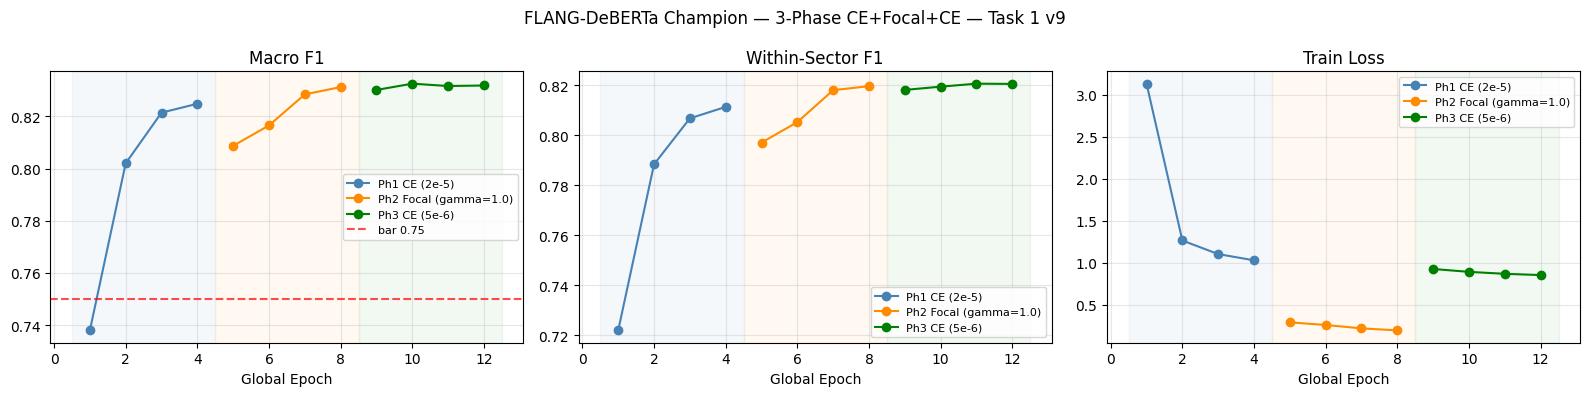

Saved.


In [ ]:
hist_df = pd.DataFrame(history)
hist_df['global_epoch'] = range(1, len(hist_df) + 1)
colors   = {1: 'steelblue', 2: 'darkorange', 3: 'green'}
labels_p = {1: 'Ph1 CE (2e-5)', 2: f'Ph2 Focal (gamma={CFG["focal_gamma"]})', 3: 'Ph3 CE (5e-6)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for phase in [1, 2, 3]:
    mask = hist_df['phase'] == phase
    if not mask.any(): continue
    ep = hist_df[mask]['global_epoch']
    c, l = colors[phase], labels_p[phase]
    axes[0].plot(ep, hist_df[mask]['macro_f1'],         color=c, marker='o', label=l)
    axes[1].plot(ep, hist_df[mask]['within_sector_f1'], color=c, marker='o', label=l)
    axes[2].plot(ep, hist_df[mask]['train_loss'],       color=c, marker='o', label=l)
    for ax in axes:
        ax.axvspan(ep.min()-0.5, ep.max()+0.5, alpha=0.05, color=c)

axes[0].axhline(0.75, color='red', ls='--', alpha=0.7, label='bar 0.75')
axes[0].set_title('Macro F1')
axes[1].set_title('Within-Sector F1')
axes[2].set_title('Train Loss')
for ax in axes:
    ax.set_xlabel('Global Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('FLANG-DeBERTa Champion — 3-Phase CE+Focal+CE — Task 1 v9', fontsize=12)
plt.tight_layout()
plt.savefig(ART_DIR / 'training_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved.')

In [ ]:
torch.save(best_state, ART_DIR / 'best_model_state.pt')
np.save(ART_DIR / 'task1_flangbert_champion_test_logits.npy', y_probs_final)

import pickle
with open(ART_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open(ART_DIR / 'label_encoder_sector.pkl', 'wb') as f:
    pickle.dump(le_sec, f)
with open(ART_DIR / 'label_encoder_group.pkl', 'wb') as f:
    pickle.dump(le_grp, f)

print('All artifacts saved.')
print(f'Final macro F1: {final_m["macro_f1"]:.4f}')

All artifacts saved.
Final macro F1: 0.8325
